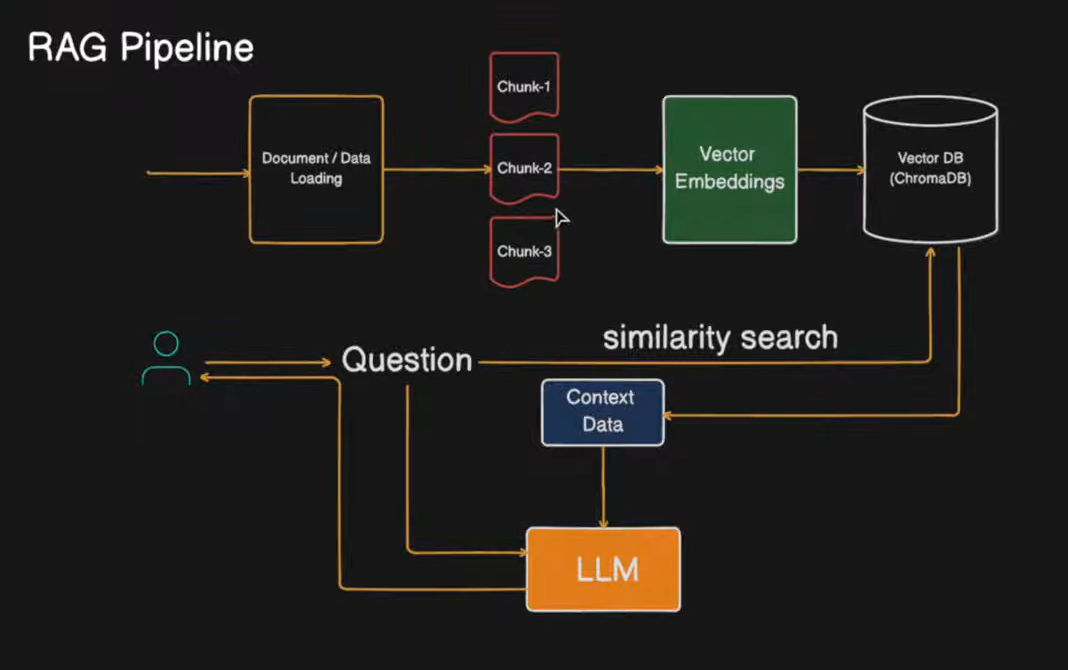

In [32]:
from IPython.display import Image, display

img_path = r"D:\GENAI\Images\Rag.png"
display(Image(filename=img_path))

In [9]:
from dotenv import load_dotenv
load_dotenv()

True

In [10]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings,ChatOllama
from langchain_chroma import Chroma 
from langchain_core.prompts import ChatPromptTemplate

In [11]:
loader=PyPDFLoader(r"C:\Users\ashut\Downloads\Gen AI Workflow Specialist-Engineer.pdf")
docs=loader.load()
len(docs)

4

In [12]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
splitted_data=splitter.split_documents(docs)
len(splitted_data)

8

In [13]:
embedding=OllamaEmbeddings(model="mxbai-embed-large")

In [14]:
vectorstore=Chroma.from_documents(
    documents=splitted_data,
    embedding=embedding,
    )

In [15]:
query="What are the responsibilities of a Gen AI Workflow Specialist-Engineer?"
data=vectorstore.similarity_search(query)

In [16]:
len(data)

4

In [17]:
context=""
for doc in data:
    context+=doc.page_content+"\n"

In [18]:
llm=ChatOllama(model="llama3.2:latest")
#res=llm.invoke(f"""Answer the question based on the 
 #              following context:\n\n{context}\n\nQuestion:{query}""")


In [19]:
#print(res.content)

In [20]:
# Chain - Context_generate + Prompt + llm + strparser

In [21]:
def get_context(query:str):
    data=vectorstore.similarity_search(query)
    context=""
    for doc in data:
        context+=doc.page_content+"\n"
    return {
        "context":context,
        "query":query
    }

In [22]:
prompt=ChatPromptTemplate.from_messages(
    [
        ("system","You are a helpful assistant for answering questions related to Gen AI Workflow Specialist-Engineer role."),
        ("human","Answer the question based on the following context:\n\n{context}\n\nQuestion:{query}")
    ]
)

In [23]:
rag_chain=get_context|prompt|llm

In [24]:
res=rag_chain.invoke("What is the duration of the Gen AI Workflow Specialist-Engineer role?")

In [25]:
print(res.content)

According to the provided context, the duration of the Gen AI Workflow Specialist-Engineer role can be categorized as follows:

- Junior: 0-2 years
- Senior: 3-5 years


In [28]:
res=rag_chain.invoke("Who is president of US?")

In [29]:
print(res.content)

I don't have any information about the current President of the United States. The provided context is related to a Gen AI Workflow Specialist / Engineer role at Craving Digital Studio Pvt. Ltd., and it doesn't mention anything about politics or the presidency. If you need information about the current President of the US, I suggest checking a reliable news source or the official website of the White House.
